# Study walkthrough

Install from the repository README first. Start this notebook from notebooks/ or the checkout. All calculations below use bundled extracted data; no quantum jobs or network requests run. See docs/REVIEW_GUIDE.md for independent review.


In [1]:
from pathlib import Path
import json
import pandas as pd
from atcgu.cli import repository_root
root = repository_root(None)
study = json.loads((root / "config/study.json").read_text())
study


{'schema_version': '1.0',
 'scope': 'Continuum analysis, Figure 1 and the SI microsolvation sensitivity (entropy treatments and 64 placement combinations)',
 'reference_family': 'adenine',
 'hartree_to_kcal_mol': 627.5094740631,
 'family_panels': {'targeted_10': ['adenine',
   'cytosine',
   'guanine',
   'thymine',
   'uracil',
   'xanthine',
   'melamine',
   'imidazole',
   'tap_c5link',
   'barbituric_acid_clink'],
  'canonical_5': ['adenine', 'cytosine', 'guanine', 'thymine', 'uracil']},
 'harmonic_thermochemistry': {'temperature_k': 298.0, 'pressure_atm': 1.0},
 'panel_c_display_convention': {'temperature_k': 298.0,
  'gas_constant_kcal_mol_k': 0.0019872041,
  'gas_to_solution_factor': 24.453091396947848,
  'water_reservoir_molarity': 55.34,
  'hartree_to_kcal_mol': 627.509474},
 'sampling': {'crest': 'GFN2-xTB, ALPB water, default iMTD-GC, 6 kcal/mol retained window',
  'heavy_atom_rmsd_cutoff_angstrom': 0.5,
  'include_dft_seed': True,
  'selection_rules': [{'moieties': ['nucle

## Inspect one complete record

Geometry coordinates are Å, all frequencies are cm⁻¹ and electronic/correction energies are hartree per particle.


In [2]:
from atcgu.records import read_bundle
record = read_bundle(root, "data/calculations/calc_557d5df31f5d3868/record.json")
{"source": record["source_log_name"], "G": record["electronic_energy_hartree"] + record["thermal_gibbs_correction_hartree"], "all_modes": len(record["frequencies_cm1"]), "minimum_mode": min(record["frequencies_cm1"])}


{'source': '1_methyluracil_pcm_water.log',
 'G': -454.225805887,
 'all_modes': 39,
 'minimum_mode': 110.8887}

## Reproduce in a fresh temporary run

The same public workflow generates the tables, Figure 1, the SI fixed-reference placement figure and the separate rank-occupancy figure, and runs every published-result comparison. This cell uses a preview PNG resolution (200 dpi); the release command defaults to 1200 dpi.

In [3]:
import tempfile
from atcgu.runner import run
review_dir = Path(tempfile.mkdtemp(prefix="atcgu_notebook_")) / "review"
run(root, review_dir, dpi=200)
pd.read_csv(review_dir / "reproduction_checks.csv")


,check_id,passed,rows,maximum_numeric_difference,tolerance
0,continuum/07_reaction_energies.csv,True,186,1.776357e-15,1.000000e-09
1,continuum/09_relative_rankings.csv,True,186,1.776357e-15,1.000000e-09
2,continuum/05_selected_species.csv,True,206,2.273737e-13,1.000000e-09
3,continuum/04_analysis_candidates.csv,True,503,2.273737e-13,1.000000e-09
4,continuum/10_legacy_vs_transferred_audit.csv,True,45,4.440892e-16,1.000000e-09
5,continuum/01_input_inventory.csv,True,408,0.000000e+00,1.000000e-09
6,continuum/02_log_validation.csv,True,408,0.000000e+00,1.000000e-09
7,"continuum/02_log_validation.csv [failures, non...",True,405,0.000000e+00,1.000000e-09
8,continuum/03_thermochemistry.csv [usable rows],True,405,0.000000e+00,1.000000e-09
9,continuum/06_sampling_coverage.csv,True,81,0.000000e+00,1.000000e-09


In [4]:
rankings = pd.read_csv(review_dir / "tables/09_relative_rankings.csv")
rankings.loc[(rankings.analysis_id == "full21_b3lyp_pcm") & (rankings.reaction_id == "P1_total_net_nucleotide_formation"), ["reaction_family_id", "relative_g_kcal_mol", "rank_within_panel"]].sort_values("rank_within_panel")


,reaction_family_id,relative_g_kcal_mol,rank_within_panel
42,adenine,0.000000,1
53,cytosine,0.355554,2
47,melamine,3.704274,3
52,imidazole,4.386286,4
45,tap_c5link,4.882332,5
56,guanine,5.156030,6
55,5_amino_4_imidazolecarboxamide,5.363933,7
60,hypoxanthine,5.997372,8
43,barbituric_acid_clink,6.128333,9
51,dihydrouracil,6.581994,10


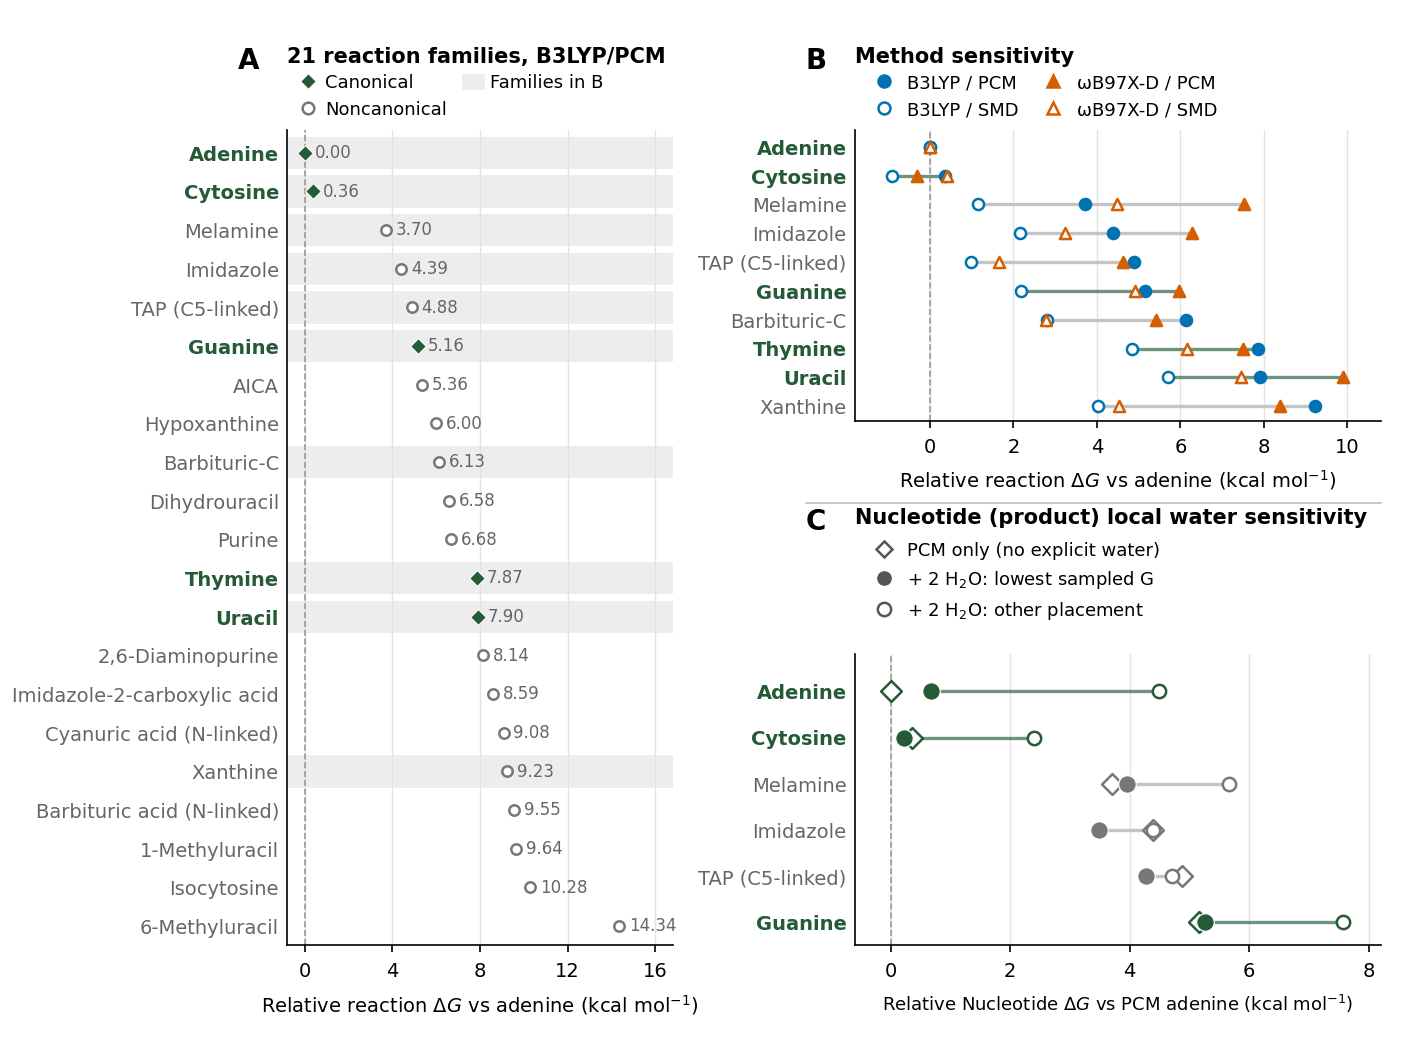

In [5]:
from IPython.display import Image, display
display(Image(filename=str(review_dir / "figures/figure1.png")))


## Trace one Figure 1C point to its record

The filled cytosine circle in Figure 1C is the lower-G two-water placement. Follow it from the selection table to the calculation bundle: `record.json` holds the energies and provenance, `optimized.xyz` the final geometry including both waters, and `frequencies.csv` every vibrational mode.

In [6]:
selected = pd.read_csv(review_dir / "tables/micro_06_primary_selected_candidates.csv")
cytosine = selected.set_index("family").loc["cytosine"]
cytosine[["candidate_id", "placement", "calculation_id", "record_path", "g_hartree", "relative_g_kcal_mol", "rank"]]

candidate_id           cytosine_ribose_phosphate_conf2_w2_splitB_pcm_...
placement                                                         splitB
calculation_id                                     calc_209cce8566547aff
record_path            data/calculations/calc_209cce8566547aff/record...
g_hartree                                                     -1612.1008
relative_g_kcal_mol                                            -0.442336
rank                                                                   1
Name: cytosine, dtype: object

In [7]:
cluster = read_bundle(root, cytosine.record_path)
bundle = (root / cytosine.record_path).parent
print(sorted(p.name for p in bundle.iterdir()))
print("\n".join((bundle / cluster["geometry_file"]).read_text().splitlines()[:5]))
print((bundle / "frequencies.csv").read_text().splitlines()[:4])
{"G = E + G_corr": cluster["electronic_energy_hartree"] + cluster["thermal_gibbs_correction_hartree"],
 "table G": float(cytosine.g_hartree), "modes": len(cluster["frequencies_cm1"]), "lowest mode (cm^-1)": min(cluster["frequencies_cm1"])}

['frequencies.csv', 'optimized.xyz', 'record.json', 'starting.xyz']
41
calc_209cce8566547aff; angstrom; atom order from source job; valid
P 2.452484 -1.089609 -0.099945
O -0.112473 1.154075 -1.276122
O 0.656973 3.764384 1.014677
['mode_index,frequency_cm1', '1,15.7812', '2,21.1896', '3,26.9896']


{'G = E + G_corr': -1612.10080043,
 'table G': -1612.10080043,
 'modes': 117,
 'lowest mode (cm^-1)': 15.7812}

## Apply an entropy treatment to one record

`treated_energies` keeps E, ZPE and H and changes only the vibrational entropy. The 50 cm⁻¹ floor raises every softer mode to 50 cm⁻¹ for its entropy. Values are hartree per particle.

In [8]:
import math
from atcgu.analysis.thermochemistry_sensitivity import treated_energies, entropy_floor_shift_hartree
from atcgu.constants import HARTREE_TO_KCAL_MOL
treated = treated_energies(cluster)
soft = [f for f in cluster["frequencies_cm1"] if f < 50]
{"modes below 50 cm^-1": len(soft),
 "floor_50 shift (kcal/mol)": (treated["floor_50"] - treated["harmonic"]) * HARTREE_TO_KCAL_MOL,
 "matches direct call": math.isclose(entropy_floor_shift_hartree(cluster["frequencies_cm1"], cluster["temperature_k"], 50.0), treated["floor_50"] - treated["harmonic"], abs_tol=1e-12),
 **{name: value for name, value in treated.items()}}

{'modes below 50 cm^-1': 6,
 'floor_50 shift (kcal/mol)': 2.061819039928252,
 'matches direct call': True,
 'harmonic': -1612.10080043,
 'floor_50': -1612.0975147122138,
 'floor_100': -1612.0918811946894,
 'grimme_qrrho_100': -1612.0935180307588}

## The 64 placement combinations

Each treatment fixes one placement per family (bit 0 = splitA, 1 = splitB, in the order adenine, cytosine, imidazole, melamine, TAP, guanine), giving 64 rankings. The summary counts distinct orders, the combinations in which adenine and cytosine are the lowest two, and how many of the 15 family pairs keep their continuum sign.

In [9]:
pd.read_csv(review_dir / "tables/si/thermochemical_summary.csv")

,treatment,selected_order,c_minus_a,pairwise_retained,unique_placement_orders,ac_top_two_choices
0,floor_100,cytosine < adenine < imidazole < melamine < ta...,-0.011223,15,15,36
1,floor_50,cytosine < adenine < imidazole < melamine < ta...,-0.071258,14,18,32
2,grimme_qrrho_100,cytosine < adenine < imidazole < melamine < ta...,-0.239476,15,18,32
3,harmonic,cytosine < adenine < imidazole < melamine < ta...,-0.442336,13,24,32


In [10]:
vectors = pd.read_csv(review_dir / "tables/si/09_placement_combinations.csv", dtype={"choice_bits": str})
harmonic = vectors.loc[vectors.treatment.eq("harmonic")]
print("C - A over 64 harmonic combinations: %.2f to %.2f kcal/mol" % (harmonic.c_minus_a_kcal_mol.min(), harmonic.c_minus_a_kcal_mol.max()))
harmonic.rank_order.value_counts().head(8)

C - A over 64 harmonic combinations: -4.26 to 1.74 kcal/mol


rank_order
cytosine < adenine < imidazole < melamine < tap < guanine    4
cytosine < imidazole < adenine < tap < melamine < guanine    4
cytosine < imidazole < adenine < tap < guanine < melamine    4
cytosine < melamine < tap < imidazole < adenine < guanine    4
cytosine < melamine < imidazole < adenine < tap < guanine    4
cytosine < imidazole < melamine < tap < adenine < guanine    4
cytosine < imidazole < melamine < adenine < tap < guanine    4
adenine < cytosine < imidazole < melamine < tap < guanine    4
Name: count, dtype: int64

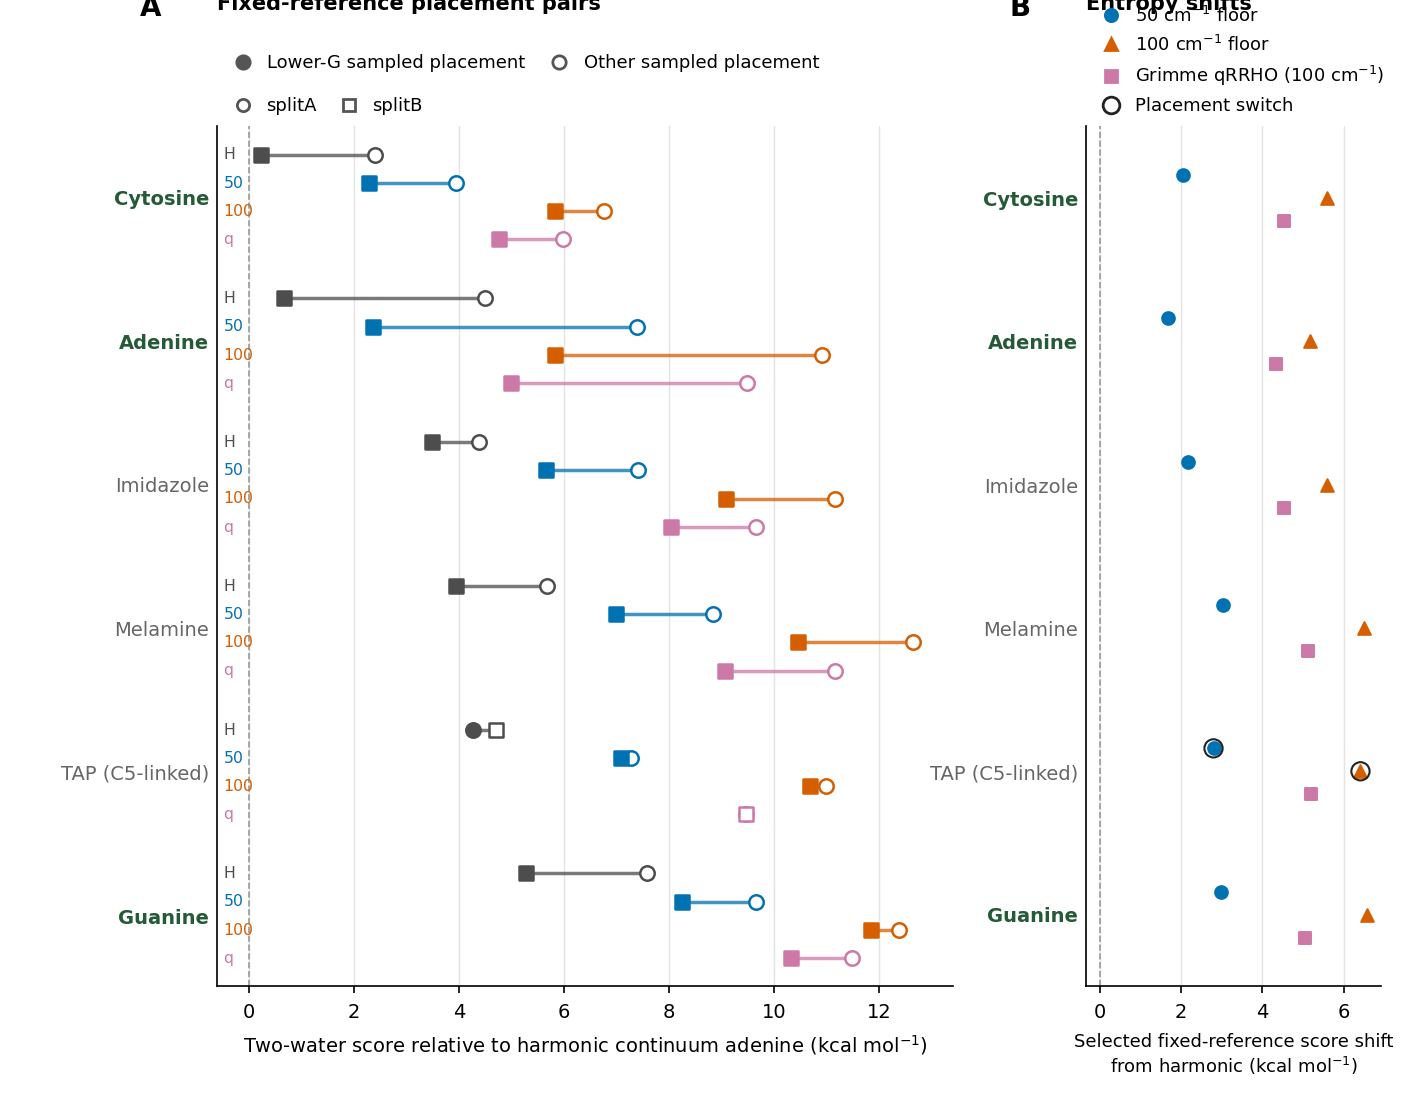

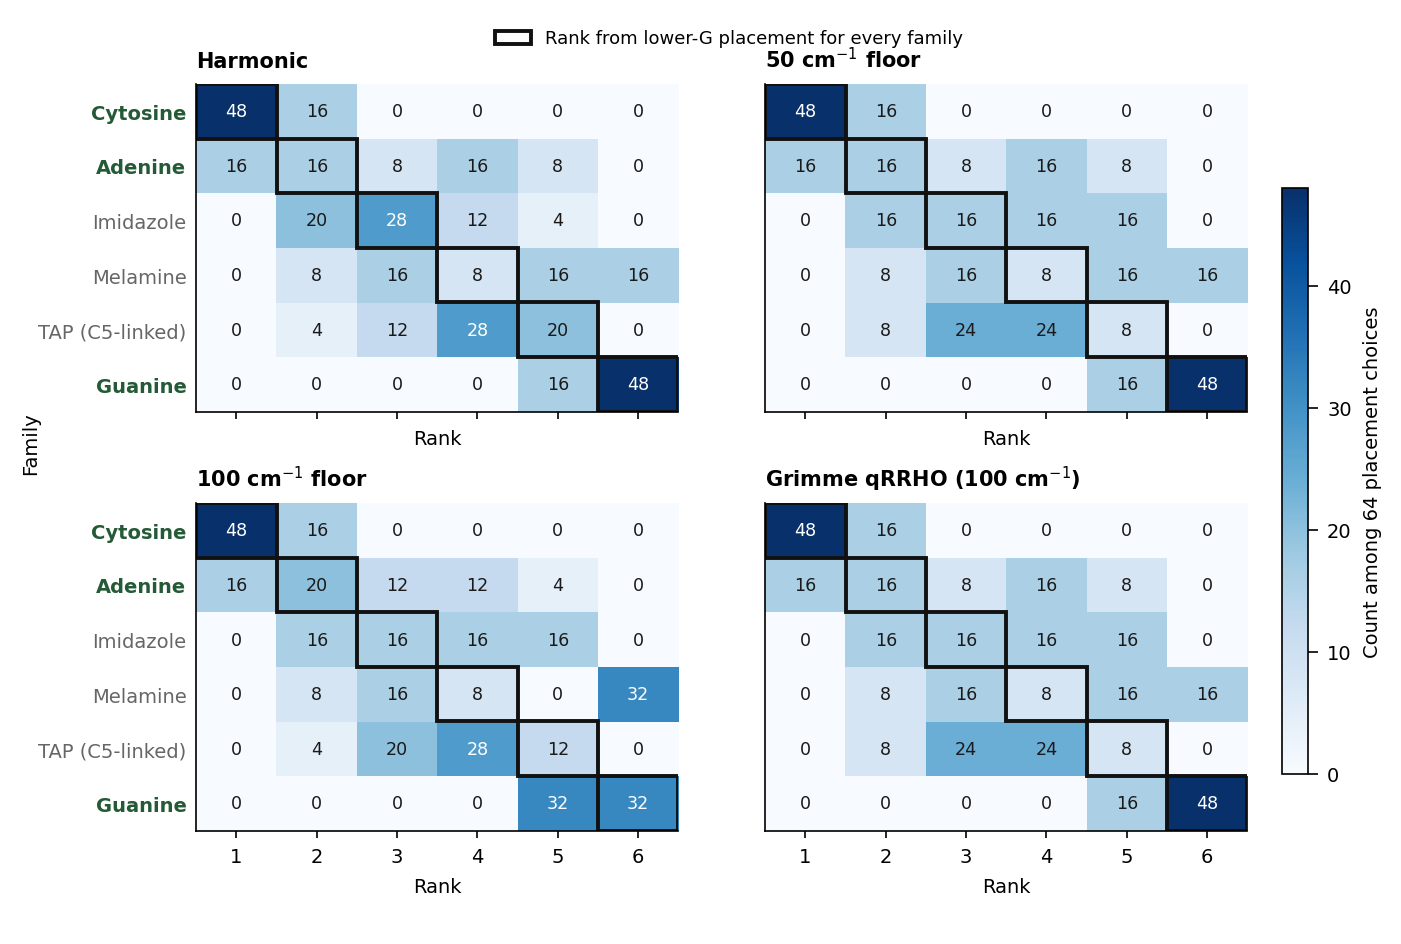

In [11]:
display(Image(filename=str(review_dir / "figures/si_microsolvation_sensitivity.png")))
display(Image(filename=str(review_dir / "figures/si_microsolvation_ranking_occupancy.png")))

## Independent arithmetic audit

This implementation imports no production analysis functions. The original source logs are deliberately absent; re-extraction cannot be repeated from the public release.


In [12]:
from atcgu.validation.arithmetic import audit
audit_dir = review_dir.parent / "independent"
audit(root, audit_dir)
json.loads((audit_dir / "summary.json").read_text())


{'checks': 2793,
 'failed_checks': 0,
 'selected_species': 206,
 'reaction_quantities': 186,
 'figure_points': 79,
 'si_placement_vectors': 256,
 'maximum_numeric_error': 1.7834889121104425e-10,
 'scope': 'arithmetic, cohort selection, published Figure 1, fixed-reference SI scores, placement vectors and rank occupancy'}

## Extend the workflow

Follow docs/EXTENDING.md and examples/add_molecule/. Define chemical state, linkage and intended stereochemistry explicitly. New quantum results require running external programs; the example never fabricates them.
